IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc 

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=MSI\SQLEXPRESS;"
    "DATABASE=fintech_fraud;"
    "Trusted_Connection=yes;"
    )

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\rahul\AppData\Local\Temp\ipykernel_17084\1315347848.py:3: SyntaxWarning: invalid escape sequence '\S'
  "SERVER=MSI\SQLEXPRESS;"


In [6]:
df = pd.read_sql('SELECT * FROM transactions', conn)

C:\Users\rahul\AppData\Local\Temp\ipykernel_17084\3328404297.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM transactions', conn)


In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.619995,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660004,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798279,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.989998,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284800 non-null  float64
 2   V2      284786 non-null  float64
 3   V3      284794 non-null  float64
 4   V4      284792 non-null  float64
 5   V5      284788 non-null  float64
 6   V6      284779 non-null  float64
 7   V7      284775 non-null  float64
 8   V8      284734 non-null  float64
 9   V9      284778 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284784 non-null  float64
 12  V12     284771 non-null  float64
 13  V13     284781 non-null  float64
 14  V14     284778 non-null  float64
 15  V15     284770 non-null  float64
 16  V16     284785 non-null  float64
 17  V17     284770 non-null  float64
 18  V18     284785 non-null  float64
 19  V19     284770 non-null  float64
 20  V20     284733 non-null  float64
 21  V21     28

In [10]:
# CHECK FRAUD DISTRIBUTION 
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
# FRAUD RATE
fraud_rate = df['Class'].mean()*100
print('Frud_Rate', fraud_rate,'%')

Frud_Rate 0.1727485630620034 %


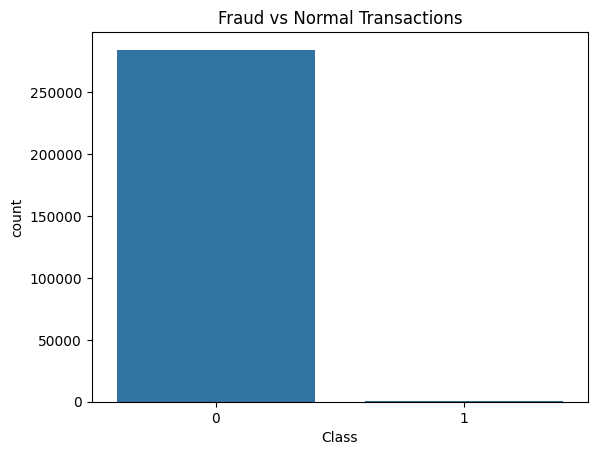

In [13]:
# FRAUD vs NORMAL VISUALIZATION
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

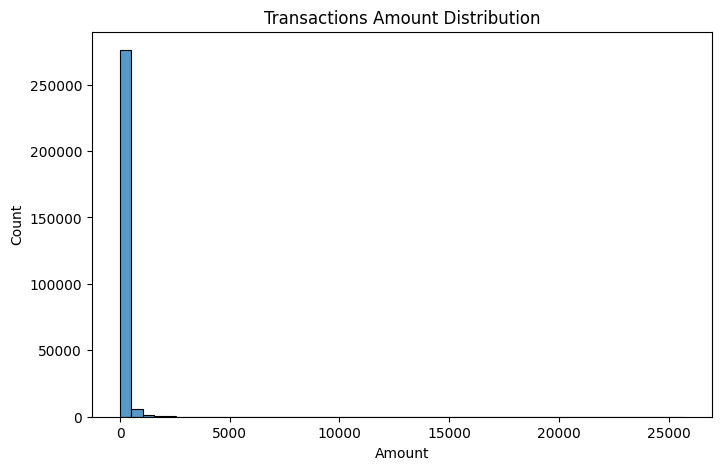

In [14]:
# TRANSACTION AMOUNT DISTRIBUTION
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transactions Amount Distribution")
plt.show()

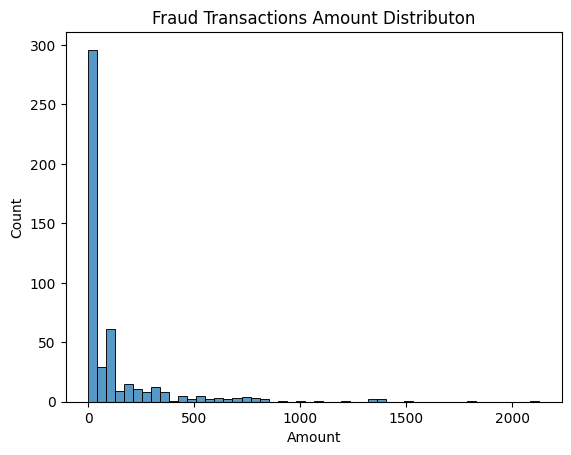

In [15]:
# FRAUD AMOUNT ANALYSIS
fraud_transactions = df[df['Class']==1]
plt.Figure(figsize=(8,5))
sns.histplot(fraud_transactions['Amount'], bins=50)
plt.title("Fraud Transactions Amount Distributon")
plt.show()

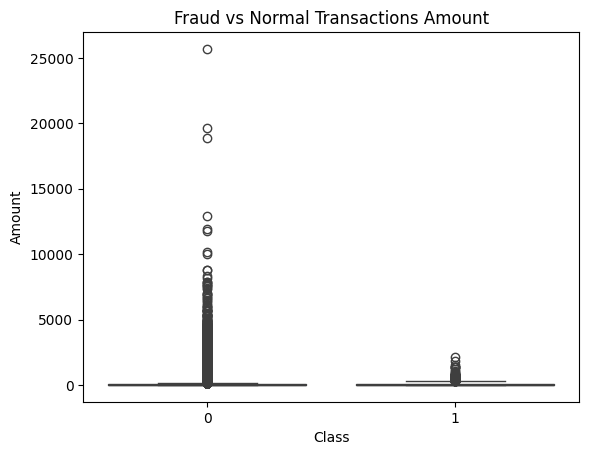

In [16]:
# COMPARE FRAUD vs NORMAL AMOUNT
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Fraud vs Normal Transactions Amount')
plt.show()

In [20]:
# FRAUD OVER TIME
df['Hour'] = df['Time']//3600

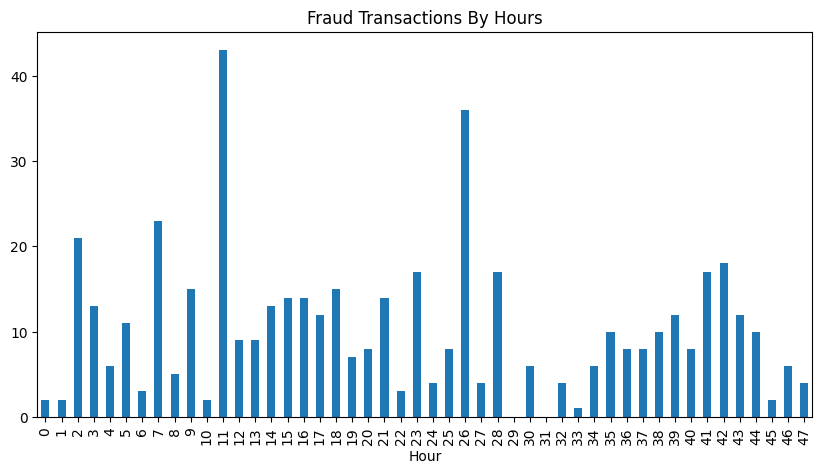

In [21]:
fraud_by_hour = df.groupby('Hour')['Class'].sum()
fraud_by_hour.plot(kind='bar', figsize=(10,5))
plt.title('Fraud Transactions By Hours')
plt.show()

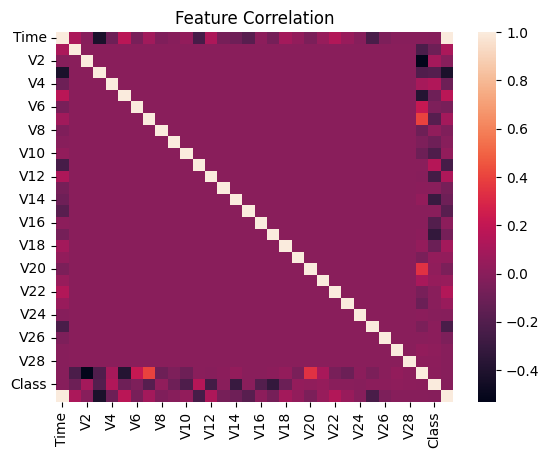

In [22]:
# CORRELATIONS ANALYSIS
plt.Figure(figsize=(10,6))
sns.heatmap(df.corr())
plt.title('Feature Correlation')
plt.show()

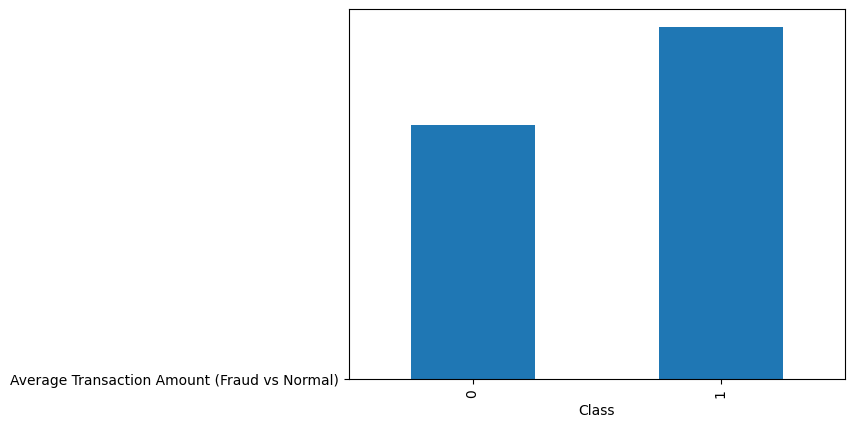

In [23]:
#FRAUD BY AMOUNT CATEGORY
fraud_by_amount = df.groupby("Class")['Amount'].mean() 
fraud_by_amount.plot(kind='bar')
plt.plot('Average Transaction Amount (Fraud vs Normal)')
plt.show()